## movie rating

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')

print(movies.shape)
print(ratings.shape)
print(movies.head())
print(ratings.head())

(9742, 3)
(100836, 4)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


In [2]:
# Merge movies and ratings
df = pd.merge(ratings, movies, on='movieId')

# Drop timestamp column
df.drop('timestamp', axis=1, inplace=True)

# Check nulls
print(df.isnull().sum())

# Basic info
print(df.describe())
print(df.dtypes)

userId     0
movieId    0
rating     0
title      0
genres     0
dtype: int64
              userId        movieId         rating
count  100836.000000  100836.000000  100836.000000
mean      326.127564   19435.295718       3.501557
std       182.618491   35530.987199       1.042529
min         1.000000       1.000000       0.500000
25%       177.000000    1199.000000       3.000000
50%       325.000000    2991.000000       3.500000
75%       477.000000    8122.000000       4.000000
max       610.000000  193609.000000       5.000000
userId       int64
movieId      int64
rating     float64
title       object
genres      object
dtype: object


In [9]:
print(movies['genres'].head(10))
print(type(movies['genres'][0]))

0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
5                          Action|Crime|Thriller
6                                 Comedy|Romance
7                             Adventure|Children
8                                         Action
9                      Action|Adventure|Thriller
Name: genres, dtype: object
<class 'str'>


['Adventure' 'Animation' 'Children' 'Comedy' 'Fantasy' 'Romance' 'Drama'
 'Action' 'Crime' 'Thriller' 'Horror' 'Mystery' 'Sci-Fi' 'War' 'Musical'
 'Documentary' 'IMAX' 'Western' 'Film-Noir']
(22050, 5)


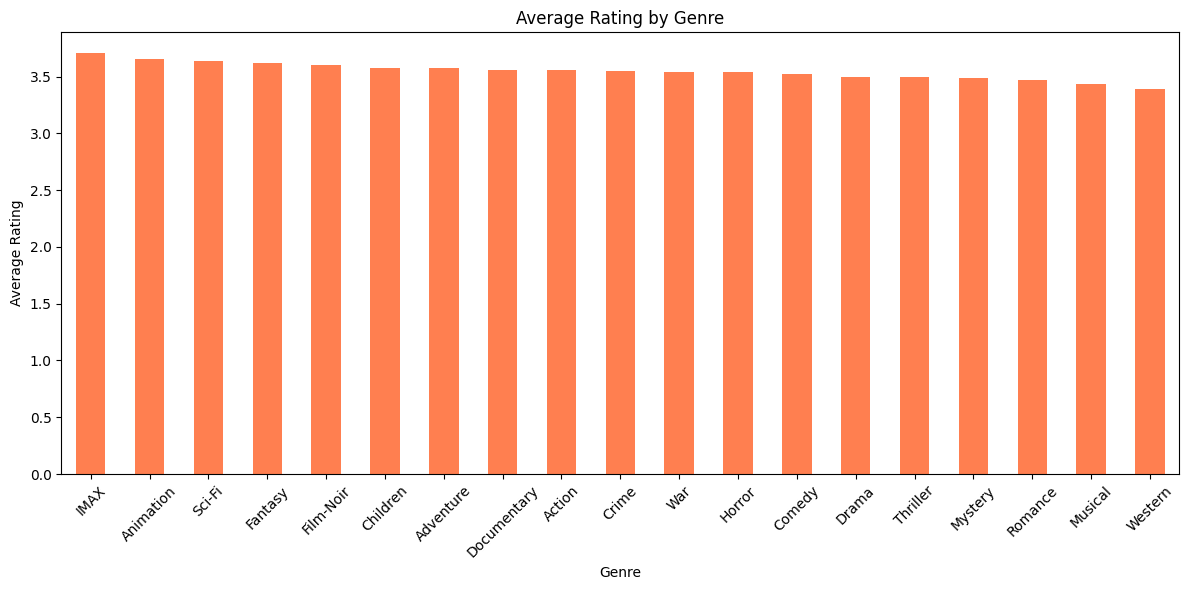

In [12]:
# 3. Average rating per genre (final fix)
df_exploded = df.copy()
df_exploded['genres'] = movies['genres']  # original string column use பண்ணு
df_exploded['genres'] = df_exploded['genres'].str.split('|')
df_exploded = df_exploded.explode('genres')
df_exploded = df_exploded[df_exploded['genres'] != '(no genres listed)']
df_exploded = df_exploded.dropna(subset=['genres'])  # nan remove பண்ணு ✅

print(df_exploded['genres'].unique())
print(df_exploded.shape)

genre_avg = df_exploded.groupby('genres')['rating'].mean()\
                       .sort_values(ascending=False)

plt.figure(figsize=(12,6))
genre_avg.plot(kind='bar', color='coral')
plt.title('Average Rating by Genre')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# Step 1 - Genre encoding
mlb = MultiLabelBinarizer()

# movies-ல இருந்து genres split பண்ணு
movies['genres_list'] = movies['genres'].str.split('|')

# df-ல genres_list merge பண்ணு
df_ml = pd.merge(ratings, movies[['movieId', 'genres_list']], on='movieId')

# Genre encode பண்ணு
genre_encoded = mlb.fit_transform(df_ml['genres_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_)

# Step 2 - Feature & Target
X = genre_df
y = df_ml['rating']

# Step 3 - Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4 - Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 5 - Predict & Evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

MAE  : 0.8178
RMSE : 1.0261
